In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv("data/Nike Dataset.csv")
print("Dataset loaded successfully!")

Dataset loaded successfully!


In [4]:
print("First 5 rows:")
df.head()

First 5 rows:


,Invoice Date,Product,Region,Retailer,Sales Method,State,Price per Unit,Total Sales,Units Sold
0,01-01-2020,Men's Street Footwear,Northeast,Foot Locker,In-store,New York,50,6000,120
1,02-01-2020,Men's Athletic Footwear,Northeast,Foot Locker,In-store,New York,50,5000,100
2,03-01-2020,Women's Street Footwear,Northeast,Foot Locker,In-store,New York,40,4000,100
3,04-01-2020,Women's Athletic Footwear,Northeast,Foot Locker,In-store,New York,45,3825,85
4,05-01-2020,Men's Apparel,Northeast,Foot Locker,In-store,New York,60,5400,90


In [5]:
rows, columns = df.shape

print("Number of rows:", rows)
print("Number of columns:", columns)

Number of rows: 9360
Number of columns: 9


In [6]:
print("Data types:")
print(df.dtypes)

Data types:
Invoice Date      object
Product           object
Region            object
Retailer          object
Sales Method      object
State             object
Price per Unit     int64
Total Sales        int64
Units Sold         int64
dtype: object


In [8]:
df.describe()

,Price per Unit,Total Sales,Units Sold
count,9360.000000,9360.00000,9360.000000
mean,44.739209,921.93109,25.852991
std,14.506338,1413.84279,21.591922
min,7.000000,0.00000,0.000000
25%,35.000000,42.00000,11.000000
50%,45.000000,95.00000,18.000000
75%,55.000000,1463.00000,35.000000
max,110.000000,8250.00000,128.000000


In [9]:
missing_values = df.isnull().sum()

print(missing_values)

Invoice Date      0
Product           0
Region            0
Retailer          0
Sales Method      0
State             0
Price per Unit    0
Total Sales       0
Units Sold        0
dtype: int64


In [12]:
total_sales = df["Total Sales"].sum()
total_quantity = df["Units Sold"].sum()

print("Total Sales:", total_sales)
print("Total Quantity Sold:", total_quantity)

Total Sales: 8629275
Total Quantity Sold: 241984


In [14]:
product_sales = (
    df.groupby("Product")["Total Sales"]
    .sum()
    .sort_values(ascending=False)
)
print(product_sales)

Product
Men's Street Footwear        1999192
Women's Apparel              1720630
Men's Athletic Footwear      1468116
Women's Street Footwear      1224756
Men's Apparel                1192682
Women's Athletic Footwear    1023899
Name: Total Sales, dtype: int64


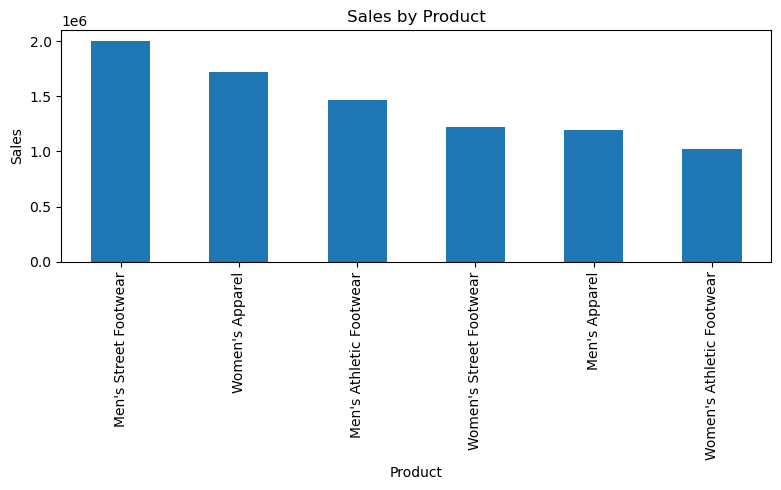

In [18]:
plt.figure(figsize=(8, 5))

product_sales.plot(kind="bar")

plt.title("Sales by Product")
plt.xlabel("Product")
plt.ylabel("Sales")

plt.tight_layout()
plt.savefig("charts/sales_by_poroduct.png", dpi=300, bbox_inches="tight")
plt.show()

In [19]:
region_sales = (
    df.groupby("Region")["Total Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(region_sales)

Region
West         2329193
Northeast    1863429
Southeast    1631786
South        1446722
Midwest      1358145
Name: Total Sales, dtype: int64


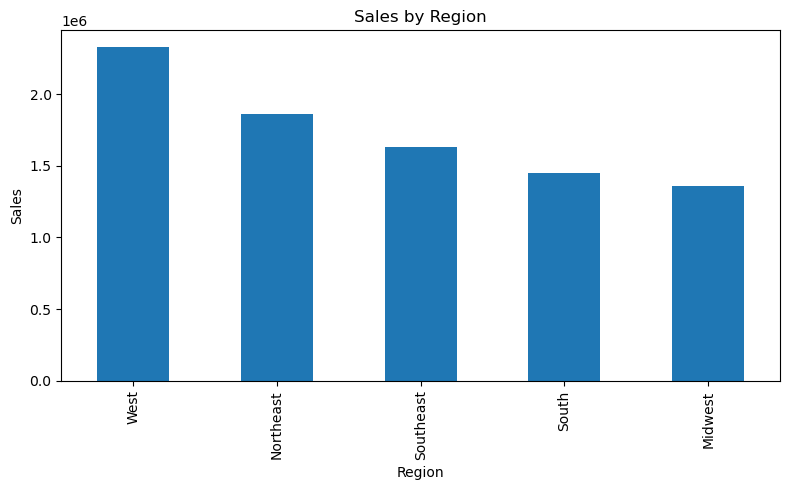

In [27]:
plt.figure(figsize=(8, 5))

region_sales.plot(kind="bar")

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.tight_layout()
plt.savefig("charts/sales_by_Region.png", dpi=300, bbox_inches="tight")
plt.show()

In [22]:
state_sales = (
    df.groupby("State")["Total Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(state_sales)

State
New York          642317
California        601768
Florida           592866
Texas             463613
South Carolina    292868
Washington        263318
North Carolina    239574
Louisiana         237520
Virginia          215753
Oregon            213509
Colorado          209975
Nevada            208586
New Mexico        198664
Idaho             192778
Georgia           189988
Michigan          186262
Wyoming           185783
Ohio              184859
Tennessee         180689
Alabama           176347
New Hampshire     164133
Arizona           157840
Montana           157124
Mississippi       155927
Vermont           143540
Arkansas          126407
Delaware          123000
Connecticut       115760
Massachusetts     110782
West Virginia     106906
Oklahoma          106219
Pennsylvania      103590
Kentucky          100737
Kansas             99733
New Jersey         99353
Illinois           97988
Utah               96972
Missouri           96846
Maine              91974
Indiana            

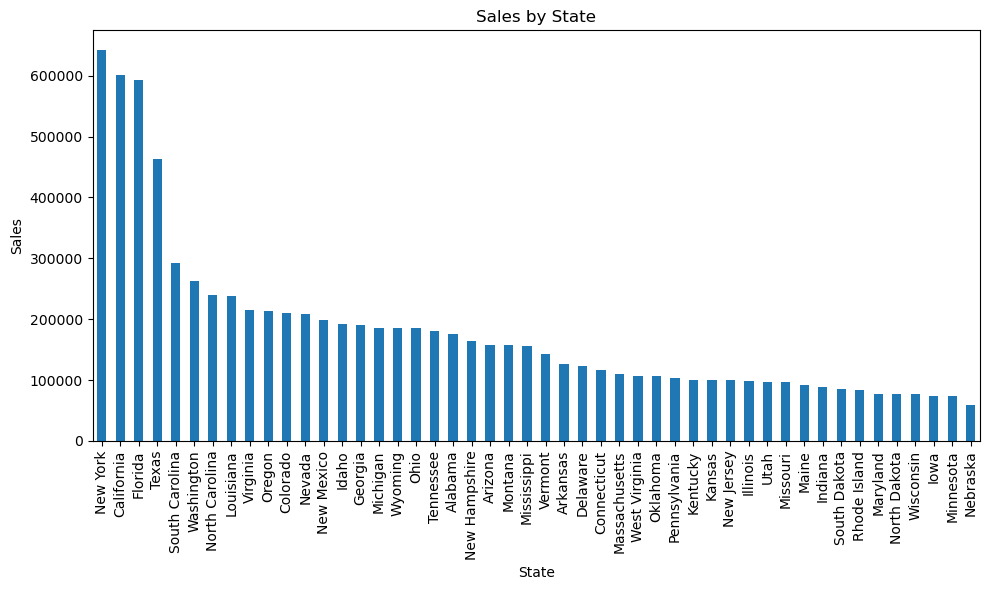

In [26]:
plt.figure(figsize=(10, 6))

state_sales.plot(kind="bar")

plt.title("Sales by State")
plt.xlabel("State")
plt.ylabel("Sales")

plt.tight_layout()
plt.savefig("charts/sales_by_State.png", dpi=300, bbox_inches="tight")
plt.show()

In [29]:
df["Invoice Date"] = pd.to_datetime(
    df["Invoice Date"],
    format="%d-%m-%Y"
)

In [30]:
sales_over_time = (
    df.groupby("Invoice Date")["Total Sales"]
    .sum()
    .sort_index()
)

print(sales_over_time)

Invoice Date
2020-01-01    8452
2020-01-02    6894
2020-01-03    6325
2020-01-04    6150
2020-01-05    7079
              ... 
2021-12-27    6024
2021-12-28    3010
2021-12-29    2112
2021-12-30    1679
2021-12-31    1988
Name: Total Sales, Length: 724, dtype: int64


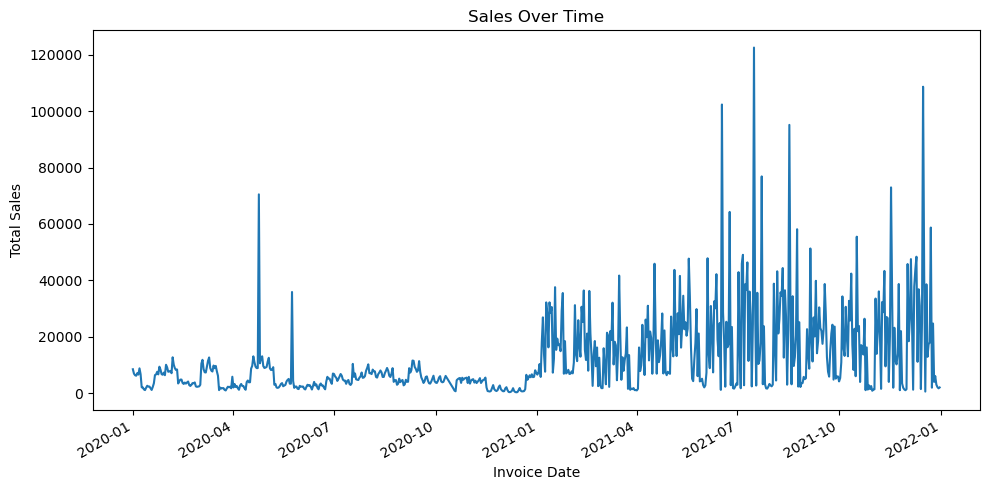

In [31]:
plt.figure(figsize=(10, 5))

sales_over_time.plot(kind="line")

plt.title("Sales Over Time")
plt.xlabel("Invoice Date")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.savefig("charts/sales_over_time.png", dpi=300, bbox_inches="tight")
plt.show()

In [32]:
correlation_matrix = df[
    ["Price per Unit", "Total Sales", "Units Sold"]
].corr()

print(correlation_matrix)

                Price per Unit  Total Sales  Units Sold
Price per Unit        1.000000     0.435680    0.270508
Total Sales           0.435680     1.000000    0.914716
Units Sold            0.270508     0.914716    1.000000


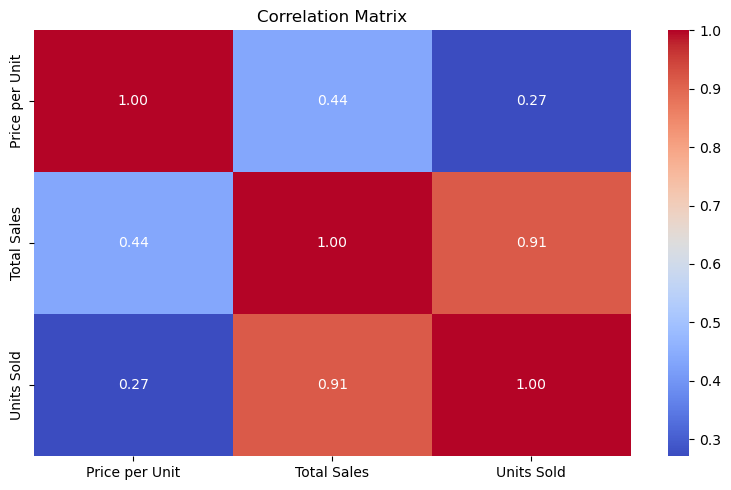

In [33]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.savefig("charts/correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()